# Plot AR7W Line from llc1080 Model

In [1]:
## import required packages
import xarray as xr
import s3fs
import zarr
import numpy as np
import pandas as pd
import netCDF4 as nc4
import boto3
import time
from pathlib import Path
from pyproj import Geod
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [ ]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:44661")
client

In [3]:
# open PHIBOT
s3_path = 's3://ecco-processed-data/SASSIE/N1/GREENLAND/ZARR/PHIBOT_AVG_DAILY.ZARR/'
phibot_ds = xr.open_zarr(s3_path)
phibot_da = phibot_ds.PHIBOT.isel(face=2)

# open ETAN
s3_path = 's3://ecco-processed-data/SASSIE/N1/GREENLAND/ZARR/ETAN_AVG_DAILY.ZARR/'
etan_ds = xr.open_zarr(s3_path)
etan_da = etan_ds.ETAN.isel(face=2)

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f8af049ba10>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f8af0437d20>, 6612.694030113)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f8af049b910>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f8af00d7c50>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f8af0437af0>, 6612.725604829)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f8af00d7b50>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f8af043a550>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f8af0437a10>, 6612.68046722)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f8af043a450>


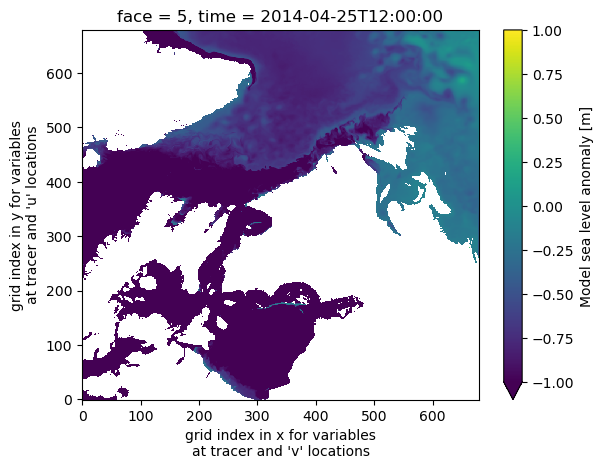

In [4]:
etan_da.isel(time=100).plot(vmin=-1,vmax=1);

In [5]:
# chunk for better processing
etan_da = etan_da.chunk({'time': -1, 'j': 50, 'i': 50})

In [6]:
# remove linear trend
p = etan_da.polyfit(dim='time', deg=1)
linear_fit = xr.polyval(etan_da.time, p.polyfit_coefficients)
etan_detrended = etan_da - linear_fit

# remove seasonal cycle
seasonal_cycle = etan_detrended.groupby('time.month').mean('time')
etan_anomaly = etan_detrended.groupby('time.month') - seasonal_cycle

/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(


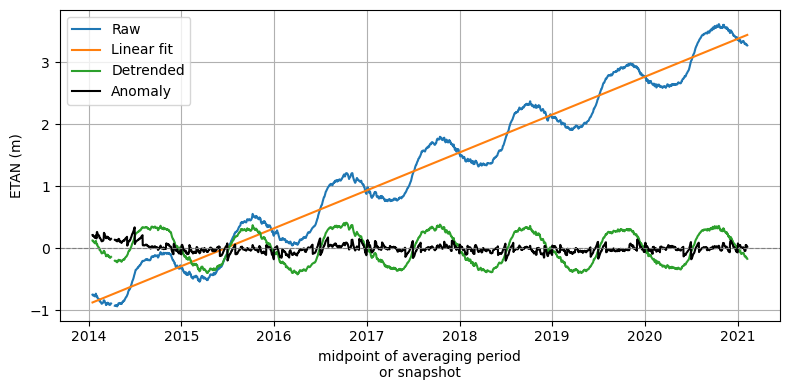

In [69]:
fig, ax = plt.subplots(figsize=(8, 4))

etan_da.mean(dim=['j', 'i']).plot(ax=ax, label='Raw')
linear_fit.mean(dim=['j', 'i']).plot(ax=ax, label='Linear fit')
etan_detrended.mean(dim=['j', 'i']).plot(ax=ax, label='Detrended')
etan_anomaly.mean(dim=['j', 'i']).plot(ax=ax, label='Anomaly', color='k')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('ETAN (m)')
ax.legend()
ax.grid()
plt.tight_layout()

In [7]:
etan_anomaly.name = 'etan_anomaly'

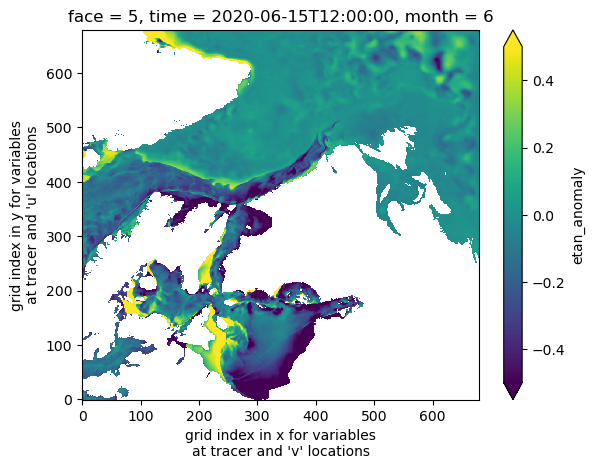

In [87]:
etan_anomaly.sel(time='2020-06-15').plot(vmin=-0.5,vmax=0.5);

In [100]:
etan_anomaly_snap = etan_anomaly.sel(time='2020-06-15')

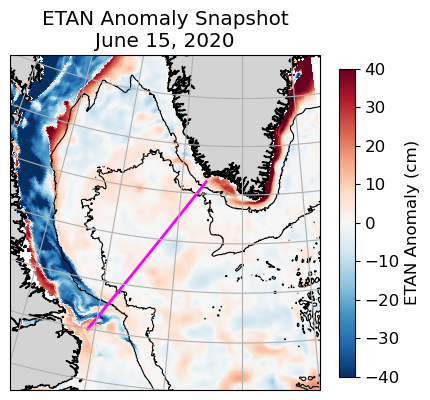

In [111]:
# plot snapshot
fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())  # Greenland region
# Add features
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False)
# Plot snapshot
pm = ax.pcolormesh(etan_anomaly_snap.XC, 
         etan_anomaly_snap.YC,
         etan_anomaly_snap.isel(time=0).values*100, cmap='RdBu_r', vmin=-40, vmax=40,
         transform=ccrs.PlateCarree())
# Colorbar
cbar = fig.colorbar(pm, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
cbar.set_label('ETAN Anomaly (cm)')
# Bathymetry contours
bathy_levels = [-3000, -1000]
cs = ax.contour(
    bathy_greenland_subsample.lon,
    bathy_greenland_subsample.lat,
    bathy_greenland_subsample,
    levels=bathy_levels,
    colors="black",
    linewidths=0.8,
    linestyles="solid",
    transform=ccrs.PlateCarree()
)
# Plot of unstructured points
plt.plot(transect.lon, 
         transect.lat,
         color='magenta', linewidth=2,
         transform=ccrs.PlateCarree())
plt.title(f"ETAN Anomaly Snapshot\nJune 15, 2020")
plt.show()

In [11]:
# save ETAN anomaly
etan_anomaly.to_netcdf('~/efs-mount-point/mzahn/data/ar7w/llc1080_etan_tile5_linear_and_seasonal_detrended.nc')

KeyboardInterrupt: 

### Isolate transect data from raw ETAN product

In [ ]:
# -----------------------------
# 1. Define transect endpoints
# -----------------------------
lat1, lon1 = 54.0, -55.5
lat2, lon2 = 60.5, -48.0

geod = Geod(ellps="WGS84")

# total distance
_, _, total_dist = geod.inv(lon1, lat1, lon2, lat2)

spacing = 10_000  # 10 km
npts = int(total_dist // spacing) + 1

# intermediate geodesic points
pts = geod.npts(lon1, lat1, lon2, lat2, npts - 2)

lons = np.array([lon1] + [p[0] for p in pts] + [lon2])
lats = np.array([lat1] + [p[1] for p in pts] + [lat2])

# -----------------------------
# 2. Distance along transect
# -----------------------------
dist = np.zeros(len(lons))
for i in range(1, len(lons)):
    _, _, d = geod.inv(lons[i-1], lats[i-1], lons[i], lats[i])
    dist[i] = dist[i-1] + d

dist_km = dist / 1000

# -----------------------------
# 3. Prepare interpolation grid
# -----------------------------
XC = etan_da.XC.values
YC = etan_da.YC.values

points = np.column_stack([
    XC.ravel(),
    YC.ravel()])

target = np.column_stack([lons, lats])

# -----------------------------
# 4. Interpolate each timestep
# -----------------------------
out = np.empty((etan_da.time.size, len(lons)))

for i in range(etan_da.time.size):
    values = etan_da.isel(time=i).values.ravel()

    out[i] = griddata(
        points,
        values,
        target,
        method="linear")

# -----------------------------
# 5. Convert to xarray
# -----------------------------
transect = xr.DataArray(
    out,
    dims=("time", "distance_km"),
    coords=dict(
        time=etan_da.time,
        distance_km=dist_km,
        lat=("distance_km", lats),
        lon=("distance_km", lons),
    ),
    name="etan_transect")

In [38]:
transect.to_netcdf('~/efs-mount-point/mzahn/data/ar7w/llc1080_etan_ar7w_transect.nc')

In [5]:
# open bathymetry
gebco_bathy_ds = xr.open_dataset('~/efs-mount-point/mzahn/data/bathy/gebco_2021_sub_ice_n90.0_s30.0_w-120.0_e30.0.nc')
bathy_greenland = gebco_bathy_ds.elevation.sel(lon=slice(-65,-35),lat=slice(50,70))

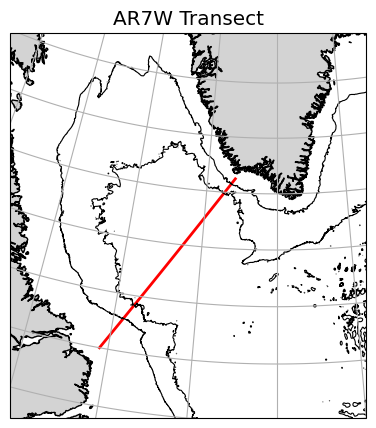

In [123]:
# plot transect

fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())  # Greenland region

# Add features
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False)

# Plot of unstructured points
plt.plot(transect.lon, 
         transect.lat,
         color='r',linewidth=2,
         transform=ccrs.PlateCarree())

# Bathymetry contours
bathy_levels = [-3000, -1000]

cs = ax.contour(
    bathy_greenland.lon,
    bathy_greenland.lat,
    bathy_greenland,
    levels=bathy_levels,
    colors="black",
    linewidths=0.8,
    linestyles="solid",
    transform=ccrs.PlateCarree()
)

plt.title(f"AR7W Transect")
plt.show()

## Open transect dataset and plot average and SD of May-July

In [6]:
transect = xr.open_dataset('~/efs-mount-point/mzahn/data/ar7w/llc1080_etan_ar7w_transect.nc').etan_transect

In [7]:
# detrend and remove seasonal cycle along the transect
p = transect.polyfit(dim='time', deg=1)
linear_fit = xr.polyval(transect.time, p.polyfit_coefficients)
transect_detrended = transect - linear_fit

seasonal_cycle = transect_detrended.groupby('time.month').mean('time')
transect_anomaly = transect_detrended.groupby('time.month') - seasonal_cycle

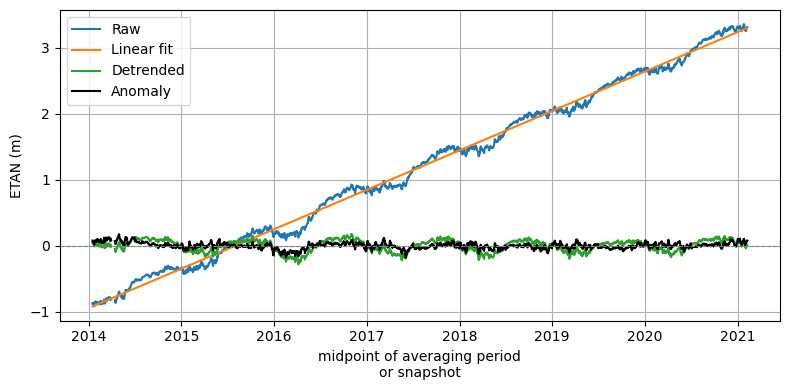

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

transect.mean('distance_km').plot(ax=ax, label='Raw')
linear_fit.mean('distance_km').plot(ax=ax, label='Linear fit')
transect_detrended.mean('distance_km').plot(ax=ax, label='Detrended')
transect_anomaly.mean('distance_km').plot(ax=ax, label='Anomaly', color='k')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('ETAN (m)')
ax.legend()
ax.grid()
plt.tight_layout()

In [9]:
# transect_summer = transect.sel(time=transect.time.dt.month.isin([5, 6, 7]))
transect_anomaly_summer = transect_anomaly.sel(time=transect_anomaly.time.dt.month.isin([5, 6, 7]))

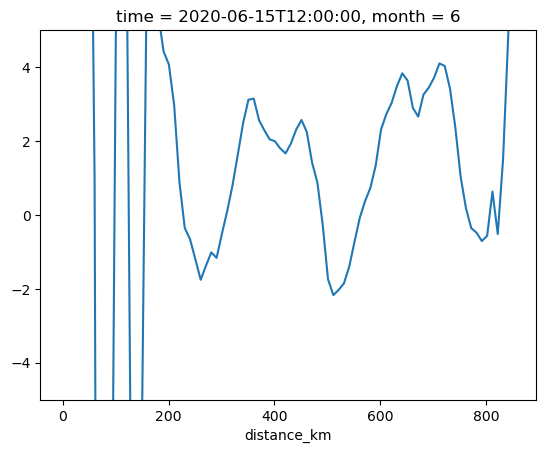

In [10]:
(transect_anomaly_summer.sel(time='2020-06-15')*100).plot();
plt.ylim(-5,5);

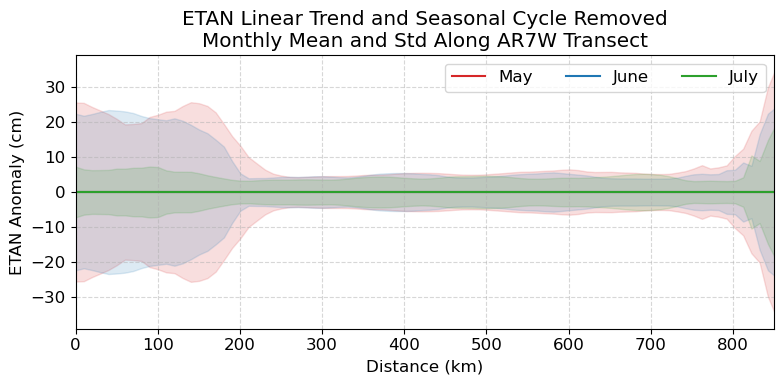

In [11]:
plt.rcParams['font.size'] = 12

# Group by month and compute mean and std
transect_summer_mean = transect_anomaly_summer.groupby('time.month').mean('time')
transect_summer_std = transect_anomaly_summer.groupby('time.month').std('time')

month_names = {5: 'May', 6: 'June', 7: 'July'}
colors = {5: 'tab:red', 6: 'tab:blue', 7: 'tab:green'}

fig, ax = plt.subplots(figsize=(8, 4))

for month in [5, 6, 7]:
    mean = transect_summer_mean.sel(month=month)*100
    std = transect_summer_std.sel(month=month)*100
    dist = transect_anomaly_summer.distance_km

    ax.plot(dist, mean, label=month_names[month], color=colors[month])
    ax.fill_between(dist, mean - std, mean + std, alpha=0.15, color=colors[month])

ax.set_title('ETAN Linear Trend and Seasonal Cycle Removed\nMonthly Mean and Std Along AR7W Transect')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('ETAN Anomaly (cm)')
ax.set_xlim(0,850)
ax.legend(ncol=3)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

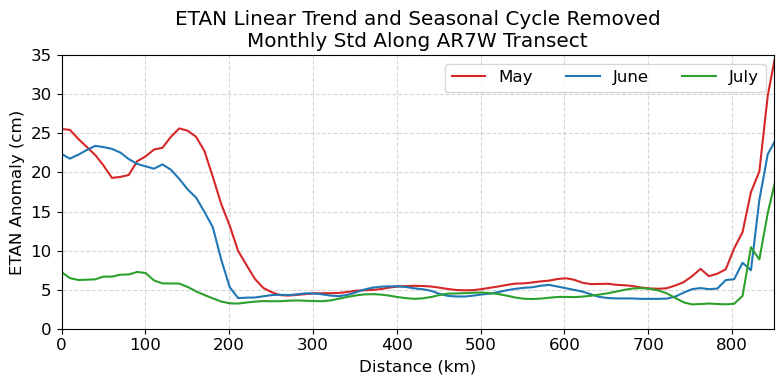

In [12]:
plt.rcParams['font.size'] = 12

# Group by month and compute mean and std
transect_summer_mean = transect_anomaly_summer.groupby('time.month').mean('time')
transect_summer_std = transect_anomaly_summer.groupby('time.month').std('time')

month_names = {5: 'May', 6: 'June', 7: 'July'}
colors = {5: 'tab:red', 6: 'tab:blue', 7: 'tab:green'}

fig, ax = plt.subplots(figsize=(8, 4))

for month in [5, 6, 7]:
    std = transect_summer_std.sel(month=month)*100
    dist = transect_anomaly_summer.distance_km

    ax.plot(dist, std, label=month_names[month], color=colors[month])

ax.set_title('ETAN Linear Trend and Seasonal Cycle Removed\nMonthly Std Along AR7W Transect')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('ETAN Anomaly (cm)')
ax.set_xlim(0,850)
ax.set_ylim(0,35)
ax.legend(ncol=3)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Subsample model for same dates as CTD data

In [10]:
# open ctd data
ctd_ds = xr.open_dataset('~/efs-mount-point/mzahn/data/ar7w/igor_ar7w.nc')

In [11]:
ctd_2019_ds = ctd_ds.sel(time='2019')

In [12]:
from pyresample import geometry, kd_tree

# Define the transect as a swath (1D along distance_km)
transect_grid = geometry.SwathDefinition(
    lons=transect_anomaly.lon.values,  # 1D along transect
    lats=transect_anomaly.lat.values   # 1D along transect
)

# Define CTD locations
ctd_grid = geometry.SwathDefinition(
    lons=ctd_2019_ds.longitude.values,
    lats=ctd_2019_ds.latitude.values
)

# Find nearest neighbour along transect for each CTD
_, _, idx, _ = kd_tree.get_neighbour_info(
    transect_grid, ctd_grid,
    radius_of_influence=50000,
    neighbours=1
)

# Now subsample transect at CTD locations and times
model_profiles = []

for n in range(len(ctd_2019_ds.time)):
    profile = transect_anomaly.isel(distance_km=idx[n]).sel(
        time=ctd_2019_ds.time.isel(time=n).values,
        method='nearest'
    )
    model_profiles.append(profile)

model_subsampled = xr.concat(model_profiles, dim='time')

In [13]:
model_subsampled

<xarray.DataArray (time: 49)> Size: 392B
array([ 0.12771141,  0.1447032 ,  0.1447032 ,  0.12714522, -0.04765456,
       -0.03264394, -0.03264394, -0.04929912, -0.02572988, -0.04748691,
       -0.05789959, -0.01848289, -0.01470769,  0.01088667, -0.0267645 ,
       -0.03636157, -0.03685069, -0.0301874 , -0.00542417,  0.02261808,
        0.02711871,  0.02809585,  0.00243449,  0.00243449,  0.00856688,
       -0.00543811, -0.01132248, -0.00687289,  0.01798056,  0.02709225,
        0.07992156,  0.07992156,  0.07992156,  0.01427274,  0.01427274,
        0.03331384,  0.01748335, -0.00450372,  0.00539031,  0.00403689,
       -0.07492792, -0.05679033, -0.02980266, -0.07127597,  0.03539206,
        0.08572499,  0.09830901,  0.10856874,  0.01412518])
Coordinates:
  * time         (time) datetime64[ns] 392B 2019-06-09T12:00:00 ... 2019-06-2...
    distance_km  (time) float64 392B 0.0 0.0 0.0 10.03 ... 110.3 70.21 200.6
    lat          (time) float64 392B 54.0 54.0 54.0 54.08 ... 54.86 54.55 55.57
    lon          (time) float64 392B -55.5 -55.5 -55.5 ... -54.67 -54.98 -53.96
    month        int64 8B 6

In [14]:
bathy_greenland_subsample = bathy_greenland.isel(lat=slice(0, None, 5),lon=slice(0, None, 5))

/tmp/ipykernel_3869/984086174.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo', 12)


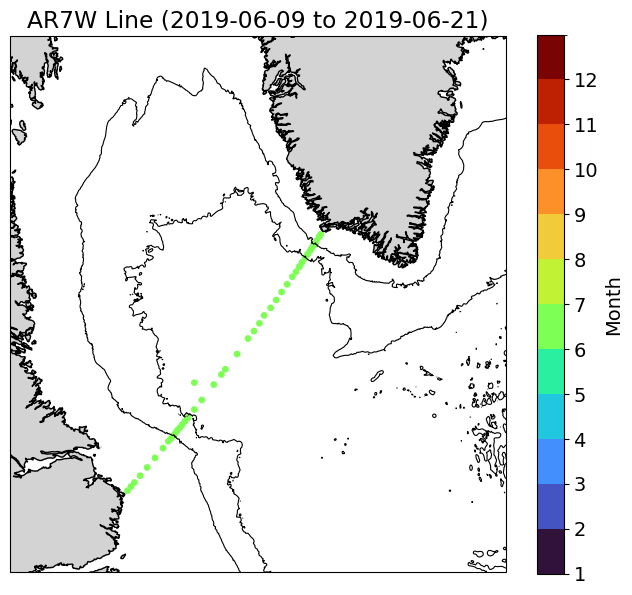

In [30]:
plt.rcParams['font.size'] = 14

# --- extract month from time ---
months = ctd_2019_ds.time.dt.month.values  # assumes xarray datetime

# --- colormap setup (1–12 months) ---
cmap = cm.get_cmap('turbo', 12)
norm = mcolors.BoundaryNorm(boundaries=range(1,14), ncolors=12)

# Plot map
fig = plt.figure(figsize=(8,7))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())

sc = ax.scatter(
    ctd_2019_ds.longitude,
    ctd_2019_ds.latitude,
    c=months,
    cmap=cmap,
    norm=norm,
    s=15,
    transform=ccrs.PlateCarree()
)

# Coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, color="lightgray")

# Bathymetry contours
bathy_levels = [-3000, -1000]
cs = ax.contour(
    bathy_greenland_subsample.lon,
    bathy_greenland_subsample.lat,
    bathy_greenland_subsample,
    levels=bathy_levels,
    colors="black",
    linewidths=0.8,
    linestyles="solid",
    transform=ccrs.PlateCarree()
)

# --- colorbar ---
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label('Month')
cbar.set_ticks(range(1,13))

# --- get date range ---
start_time = ctd_2019_ds.time.min().values
end_time = ctd_2019_ds.time.max().values

# format nicely (e.g., YYYY-MM-DD)
start_str = np.datetime_as_string(start_time, unit='D')
end_str = np.datetime_as_string(end_time, unit='D')

plt.title(f"AR7W Line ({start_str} to {end_str})")
plt.show()

In [92]:
transect_monthly_mean = transect_anomaly.groupby('time.month').mean('time')

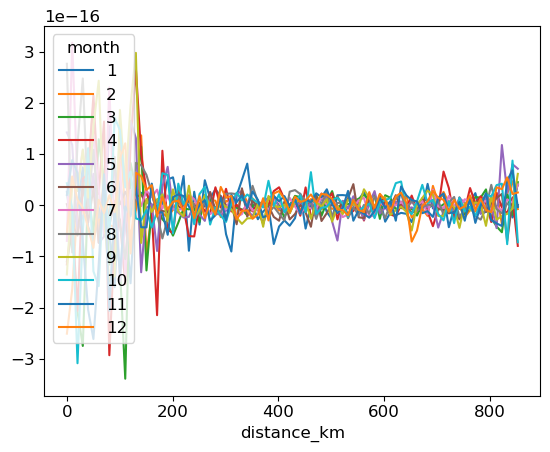

In [94]:
transect_monthly_mean.plot(hue='month');

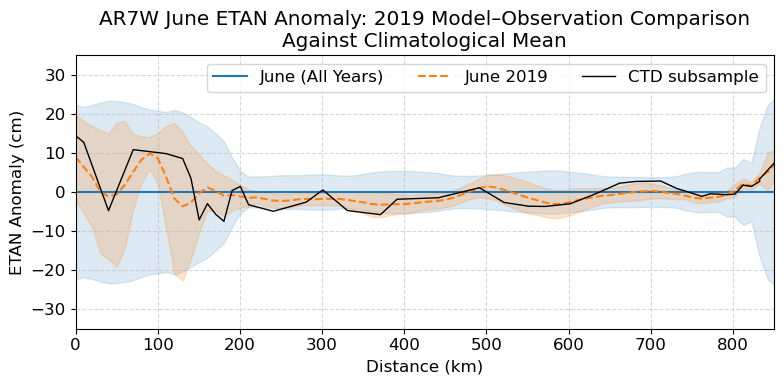

In [41]:
plt.rcParams['font.size'] = 12

# Group by month and compute mean and std (all years)
transect_summer_mean = transect_anomaly_summer.groupby('time.month').mean('time')
transect_summer_std = transect_anomaly_summer.groupby('time.month').std('time')

# Compute June mean and std for 2019 only
transect_2019_june = transect_anomaly_summer.sel(time=transect_anomaly_summer['time.year'] == 2019)
transect_2019_june = transect_2019_june.sel(time=transect_2019_june['time.month'] == 6)
mean_2019 = transect_2019_june.mean('time') * 100
std_2019 = transect_2019_june.std('time') * 100

fig, ax = plt.subplots(figsize=(8, 4))

dist = transect_anomaly_summer.distance_km

# --- All-year June mean and std ---
mean_all = transect_summer_mean.sel(month=6) * 100
std_all = transect_summer_std.sel(month=6) * 100

ax.plot(dist, mean_all, label='June (All Years)', color='tab:blue')
ax.fill_between(dist, mean_all - std_all, mean_all + std_all, alpha=0.15, color='tab:blue')

# --- 2019 June mean and std ---
ax.plot(dist, mean_2019, label='June 2019', color='tab:orange', linestyle='--')
ax.fill_between(dist, mean_2019 - std_2019, mean_2019 + std_2019, alpha=0.2, color='tab:orange')

(model_subsampled.sortby('distance_km')*100).plot(ax=ax, x='distance_km',color='k',linewidth=1,label='CTD subsample');

ax.set_title('AR7W June ETAN Anomaly: 2019 Model–Observation Comparison\nAgainst Climatological Mean')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('ETAN Anomaly (cm)')
ax.set_xlim(0, 850)
ax.set_ylim(-35, 35)
ax.legend(ncol=3)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Mimick satellite repeat cycle

In [15]:
# subsample weekly
transect_anomaly_weekly = transect_anomaly.resample(time="7D").nearest()

# interpolate back to daily for direct comparison
transect_weekly_interp = transect_anomaly_weekly.interp(time=transect_anomaly.time, method="linear")

# calculate difference/error
diff = transect_anomaly - transect_weekly_interp

rmse = np.sqrt((diff**2).mean(dim="time"))
bias = diff.mean(dim="time")

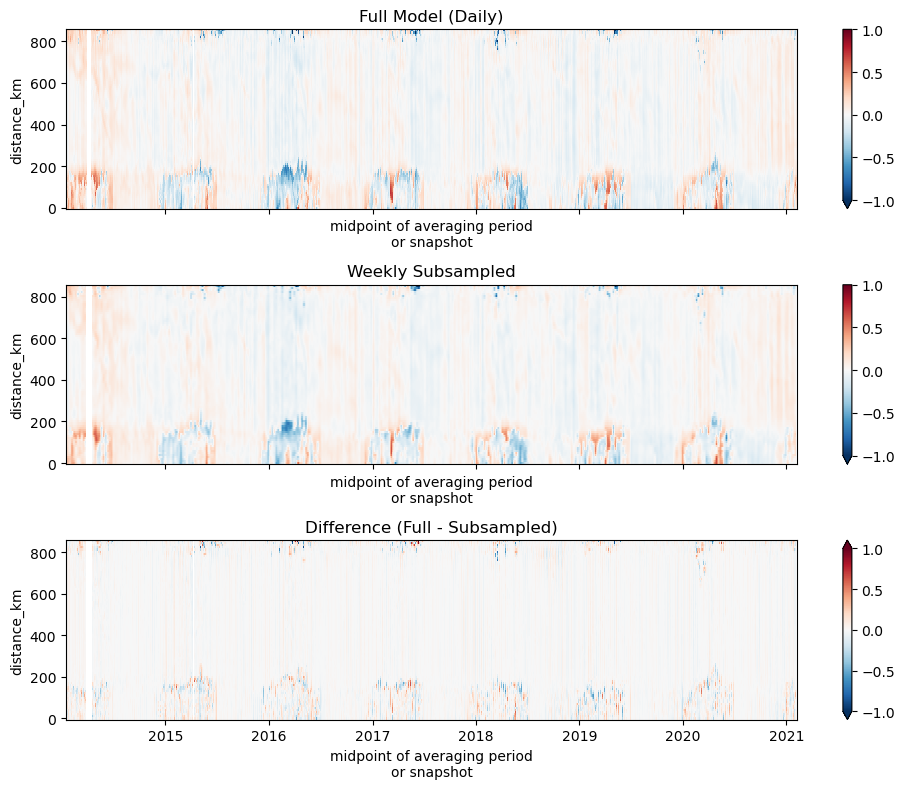

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

transect_anomaly.plot(ax=axes[0], x="time", y="distance_km", cmap="RdBu_r",vmin=-1,vmax=1)
axes[0].set_title("Full Model (Daily)")

transect_weekly_interp.plot(ax=axes[1], x="time", y="distance_km", cmap="RdBu_r",vmin=-1,vmax=1)
axes[1].set_title("Weekly Subsampled")

diff.plot(ax=axes[2], x="time", y="distance_km", cmap="RdBu_r",vmin=-1,vmax=1)
axes[2].set_title("Difference (Full - Subsampled)")

plt.tight_layout()

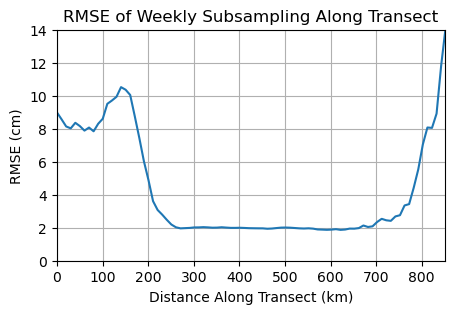

In [24]:
rmse = np.sqrt((diff**2).mean(dim="time"))
(rmse*100).plot(x="distance_km",figsize=[5,3])
plt.ylim(0,14)
plt.xlim(0,850)
plt.grid()
plt.ylabel("RMSE (cm)")
plt.xlabel("Distance Along Transect (km)")
plt.title("RMSE of Weekly Subsampling Along Transect");

### Now subsample at CTD frequency (same DOY each year - from 2019 year)

In [43]:
import numpy as np
import xarray as xr
from pyresample import geometry, kd_tree

# ── 1. Build the CTD sampling pattern (positions + day-of-year) ──────────────

transect_grid = geometry.SwathDefinition(
    lons=transect_anomaly.lon.values,
    lats=transect_anomaly.lat.values
)
ctd_grid = geometry.SwathDefinition(
    lons=ctd_2019_ds.longitude.values,
    lats=ctd_2019_ds.latitude.values
)

_, _, ctd_idx, _ = kd_tree.get_neighbour_info(
    transect_grid, ctd_grid,
    radius_of_influence=50000,
    neighbours=1
)

# Day-of-year for each CTD profile (1–366)
ctd_times = ctd_2019_ds.time.values  # numpy datetime64
ctd_doys  = [pd.Timestamp(t).day_of_year for t in ctd_times]

# ── 2. Apply that pattern to every model year ─────────────────────────────────

model_years = np.unique(transect_anomaly.time.dt.year.values)

all_profiles = []
for year in model_years[0:-1]:
    ta_year = transect_anomaly.sel(time=str(year))
    
    year_profiles = []
    for n, (doy, dist_idx) in enumerate(zip(ctd_doys, ctd_idx)):
        try:
            target_date = pd.Timestamp(year=year, month=1, day=1) + pd.Timedelta(days=doy - 1)
        except ValueError:
            target_date = pd.Timestamp(year=year, month=12, day=31)
        
        if target_date.year != year:
            continue
        
        profile = ta_year.isel(distance_km=dist_idx).sel(
            time=target_date,
            method='nearest'
        )
        profile = profile.assign_coords(
            year=year,
            doy=doy,
            ctd_sample_idx=n
        )
        year_profiles.append(profile)
    
    # Sort this year's profiles by distance_km before storing
    year_profiles.sort(key=lambda p: float(p.distance_km.values))
    all_profiles.extend(year_profiles)

# Concatenate all profiles along distance_km
model_ctd_subsampled = xr.concat(all_profiles, dim='distance_km')

In [47]:
model_ctd_subsample_2019 = model_ctd_subsampled.where(model_ctd_subsampled.year==2019,drop=True)

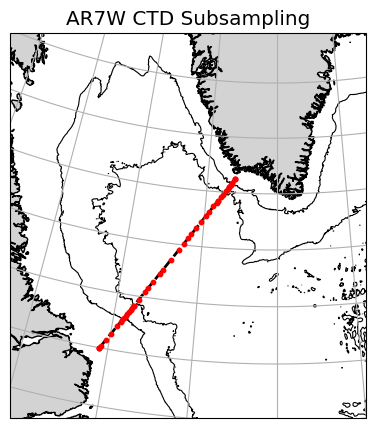

In [60]:
# plot transect

fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())  # Greenland region

# Add features
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False)

# Plot of unstructured points
plt.plot(transect.lon, 
         transect.lat,
         color='k',linewidth=2,linestyle='dashed',
         transform=ccrs.PlateCarree())

# Plot of ctd subsampling
plt.scatter(model_ctd_subsample_2019.lon, 
            model_ctd_subsample_2019.lat,
            color='r',s=10,marker='o',zorder=6,
            transform=ccrs.PlateCarree())

# Bathymetry contours
bathy_levels = [-3000, -1000]

cs = ax.contour(
    bathy_greenland_subsample.lon,
    bathy_greenland_subsample.lat,
    bathy_greenland_subsample,
    levels=bathy_levels,
    colors="black",
    linewidths=0.8,
    linestyles="solid",
    transform=ccrs.PlateCarree()
)

plt.title(f"AR7W CTD Subsampling")
plt.show()

In [70]:
model_ctd_subsampled_avg = model_ctd_subsampled.groupby('distance_km').mean()
model_ctd_subsampled_std = model_ctd_subsampled.groupby('distance_km').std()

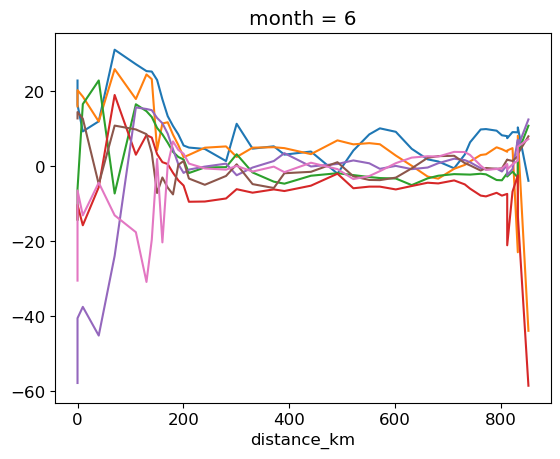

In [77]:
for year in model_years[0:-1]:
    model_ctd_subsample_yr = model_ctd_subsampled.where(model_ctd_subsampled.year==year,drop=True)*100
    model_ctd_subsample_yr.plot();

In [82]:
common_dist = np.arange(0, 851, 5)
interp_profiles = []

for year in model_years[0:-1]:
    yr_data = model_ctd_subsampled.where(model_ctd_subsampled.year == year, drop=True) * 100
    
    # Average over any duplicate distance_km values
    yr_data = yr_data.groupby('distance_km').mean()
    
    # Interpolate onto common distance grid
    yr_interp = yr_data.interp(distance_km=common_dist, method='linear')
    yr_interp = yr_interp.assign_coords(year=year)
    interp_profiles.append(yr_interp)

all_years_ds = xr.concat(interp_profiles, dim='year')

mean_subsample_transect = all_years_ds.mean(dim='year')
std_subsample_transect  = all_years_ds.std(dim='year')

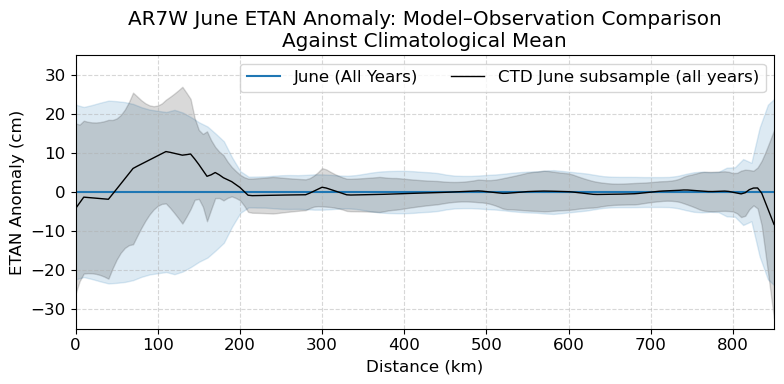

In [96]:
plt.rcParams['font.size'] = 12

# Group by month and compute mean and std (all years)
transect_summer_mean = transect_anomaly_summer.groupby('time.month').mean('time')
transect_summer_std = transect_anomaly_summer.groupby('time.month').std('time')

# Compute June mean and std for 2019 only
transect_2019_june = transect_anomaly_summer.sel(time=transect_anomaly_summer['time.year'] == 2019)
transect_2019_june = transect_2019_june.sel(time=transect_2019_june['time.month'] == 6)
mean_2019 = transect_2019_june.mean('time') * 100
std_2019 = transect_2019_june.std('time') * 100

fig, ax = plt.subplots(figsize=(8, 4))

dist = transect_anomaly_summer.distance_km

# --- All-year June mean and std ---
mean_all = transect_summer_mean.sel(month=6) * 100
std_all = transect_summer_std.sel(month=6) * 100

ax.plot(dist, mean_all, label='June (All Years)', color='tab:blue')
ax.fill_between(dist, mean_all - std_all, mean_all + std_all, alpha=0.15, color='tab:blue')

mean_subsample_transect.plot(ax=ax, x='distance_km',color='k',linewidth=1,label='CTD June subsample (all years)');
ax.fill_between(std_subsample_transect.distance_km, 
                mean_subsample_transect - std_subsample_transect, 
                mean_subsample_transect + std_subsample_transect, alpha=0.15, color='k')

ax.set_title('AR7W June ETAN Anomaly: Model–Observation Comparison\nAgainst Climatological Mean')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('ETAN Anomaly (cm)')
ax.set_xlim(0, 850)
ax.set_ylim(-35, 35)
ax.legend(ncol=3)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# ── 3. Reconstruct a continuous time series for comparison ───────────────────
# Strategy: for each year, interpolate the sparse CTD-sampled profiles back
# onto the daily model time axis (same approach as the weekly experiment).

reconstructed_years = []

for year in model_years:
    ta_year = transect_anomaly.sel(time=str(year))

    # Pull the subsampled profiles for this year
    year_mask   = model_ctd_subsampled.year == year
    year_samps  = model_ctd_subsampled.isel(sample=year_mask)

    # Build a sparse xarray with time as coordinate
    sparse = year_samps.assign_coords(time=("sample", year_samps.time.values))
    sparse = sparse.swap_dims({"sample": "time"}).sortby("time")

    # Interpolate back to daily
    recon = sparse.interp(time=ta_year.time, method="linear")
    reconstructed_years.append(recon)

transect_ctd_interp = xr.concat(reconstructed_years, dim='time')

# ── 4. Skill metrics (same as weekly experiment) ──────────────────────────────

diff_ctd  = transect_anomaly - transect_ctd_interp
rmse_ctd  = np.sqrt((diff_ctd**2).mean(dim="time"))
bias_ctd  = diff_ctd.mean(dim="time")

In [ ]:
# ── 5. Plots ──────────────────────────────────────────────────────────────────

# Hovmöller comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

transect_anomaly.plot(ax=axes[0], x="time", y="distance_km", cmap="RdBu_r")
axes[0].set_title("Full Model (Daily)")

transect_ctd_interp.plot(ax=axes[1], x="time", y="distance_km", cmap="RdBu_r")
axes[1].set_title("CTD-Pattern Subsampled (all years)")

diff_ctd.plot(ax=axes[2], x="time", y="distance_km", cmap="RdBu_r")
axes[2].set_title("Difference (Full − CTD Subsampled)")

plt.tight_layout()

# RMSE along transect — compare CTD vs weekly subsampling
rmse_weekly = np.sqrt(((transect_anomaly - transect_weekly_interp)**2).mean(dim="time"))

fig, ax = plt.subplots(figsize=(10, 4))
rmse_weekly.plot(x="distance_km", ax=ax, label="Weekly subsampling")
rmse_ctd.plot(  x="distance_km", ax=ax, label="CTD-pattern subsampling")
ax.set_ylabel("RMSE (m)")
ax.set_title("Subsampling RMSE Along Transect")
ax.legend()
plt.tight_layout()